# Obtain all neccessary imports

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.sparse import bmat, csr_matrix, diags

import ca_models_lib as caml
import os
import pandas as pd
import time

from numpy import dot, multiply, diag, power
from matplotlib.animation import FuncAnimation
from matplotlib import colors
from matplotlib import animation
from IPython.display import display, HTML

In [12]:
# Load data
folder_path_pc = r"C:\Users\steph\Box\ZartmanLabGroupFolder\Zartman_Dowling\Stephen\MC2021_Data"
folder_path_mac = r"/Users/scini/Library/CloudStorage/Box-Box/ZartmanLabGroupFolder/Zartman_Dowling/Stephen/MC2021_Data/"

folder_path = folder_path_mac
# Get geometry files

# Select size
size = 'small'  # Options: 'xsmall', 'small', 'medium', 'large',
# Load statics for wing disc geometries    
disc_vertices = np.load(os.path.join(folder_path, "geometry", "disc_vertices.npy"), allow_pickle=True).item()  # Vertices
disc_laplacians = np.load(os.path.join(folder_path, "geometry", "disc_sizes_laplacian.npy"), allow_pickle=True).item()  # Laplacian Matrix
disc_adjs = np.load(os.path.join(folder_path, "geometry", "disc_sizes_adj.npy"), allow_pickle=True).item()  # Adjacency matrix

adj_matrix=disc_adjs[size] # Adjacency Matrix
laplacian_matrix=disc_laplacians[size] # Laplacian Matrix
new_vertices=disc_vertices[size] # Vertices

# Number of cells
num_cells = new_vertices.shape[0]

In [13]:
num_cells = laplacian_matrix.shape[0]
frac = 1/num_cells**0.8  # Fraction of cells that are optogenetically stimulated
print(f"Number of cells in {size} disc: {num_cells}, frac: {frac}")

params_orig = {'K_PLC': 0.2, 'K_5':0.66, 'k_1':1.11 , 'k_a': 0.08, 'k_p':0.13, 'k_2':0.0203, 'V_SERCA':0.9, 'K_SERCA':0.1,
            'c_tot':2, 'beta':.185, 'k_i':0.4, 'D_p':0.005, 'tau_max':800, 'k_tau':1.5, 'lower':0.3, 'upper':0.8, 'frac':frac, 'D_c_ratio':0.1,
            'alpha':0.025, 'Imax': 1, 'sim_time': 1800}  # Default parameters for original model
params = {
    # 'alpha': 0.49,
    'D_p': 0,
    'frac': frac,
}
params_orig.update(params)  # Update original params with new alpha, D_p, frac

disc_model_orig = caml.Pouch_original(size=size, folder_path=folder_path, 
                                      sim_number=12345, params=params_orig)

disc_model_sparse = caml.PouchModelScipy_sparse_v2(laplacian_matrix,
                                                   random_seed=12345,
                                                   param_dict=params_orig,
                                                   save=True,

                                                #    dt=1.0,
                                                #    t_eval_boolean=True
                                                    )
disc_model_sparse_noIP3 = caml.PouchModelScipy_sparse_v2(laplacian_matrix,
                                                   random_seed=12345,
                                                   param_dict=params,
                                                   save=True,
                                                #    dt=1.0,
                                                #    t_eval_boolean=True
                                                    )
    
print(laplacian_matrix)
# Save laplacian to a csv file
# np.savetxt("laplacian_matrix.csv", laplacian_matrix, delimiter=",")
# print(disc_model_sparse.laplacian)


Number of cells in small disc: 860, frac: 0.004491601715197952
[[-28.79730262   0.           0.         ...   0.           0.
    0.        ]
 [  0.         -28.62068255   8.25470432 ...   0.           0.
    0.        ]
 [  0.           8.25470432 -31.93925371 ...   0.           0.
    0.        ]
 ...
 [  0.           0.           0.         ... -31.55348294   0.
    0.        ]
 [  0.           0.           0.         ...   0.         -25.13551289
    5.76937688]
 [  0.           0.           0.         ...   0.           5.76937688
  -22.15703475]]


In [14]:

# Simulate with and without PLC
t2 = time.perf_counter()
sig2 = disc_model_sparse.simulate(opto_bool=True, int_method='BDF', )
print(f"Step 2 took {time.perf_counter() - t2:.4f} seconds")

t3 = time.perf_counter()
sig3 = disc_model_sparse_noIP3.simulate(opto_bool=True, int_method='BDF', )
print(f"Step 3 took {time.perf_counter() - t3:.4f} seconds")


Step 2 took 43.5310 seconds
Step 3 took 9.7237 seconds


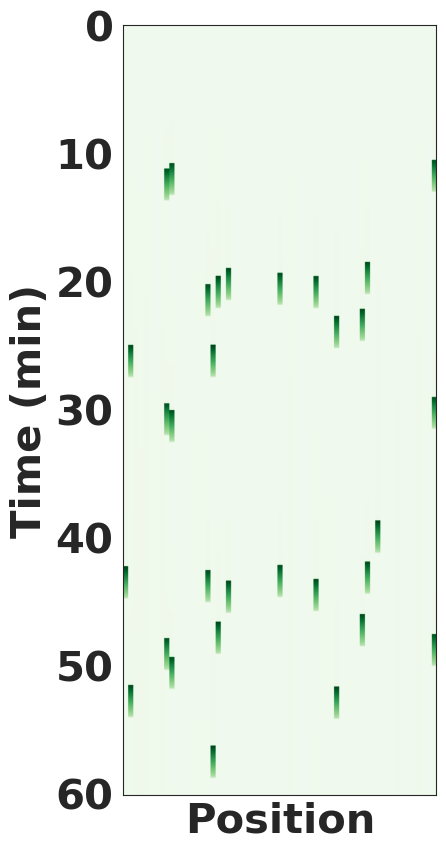

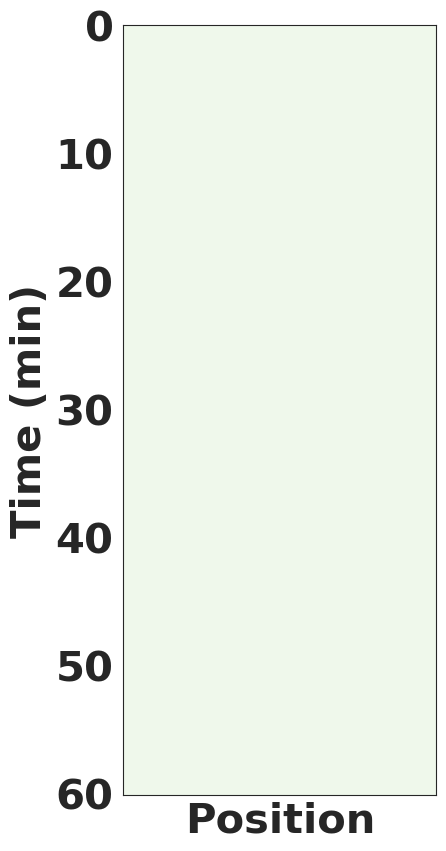

In [15]:
# Plot kymographs for each model
disc_model_sparse.new_vertices = new_vertices
disc_model_sparse.draw_kymograph(path=folder_path)

disc_model_sparse_noIP3.new_vertices = new_vertices
disc_model_sparse_noIP3.draw_kymograph(path=folder_path)

/Users/scini/Documents/GitHub/MSELab_Calcium_Cartography_2021/ca_models_lib.py:402: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  cbar.ax.set_yticklabels(cbar.ax.get_yticklabels(), fontsize=15,fontweight="bold")


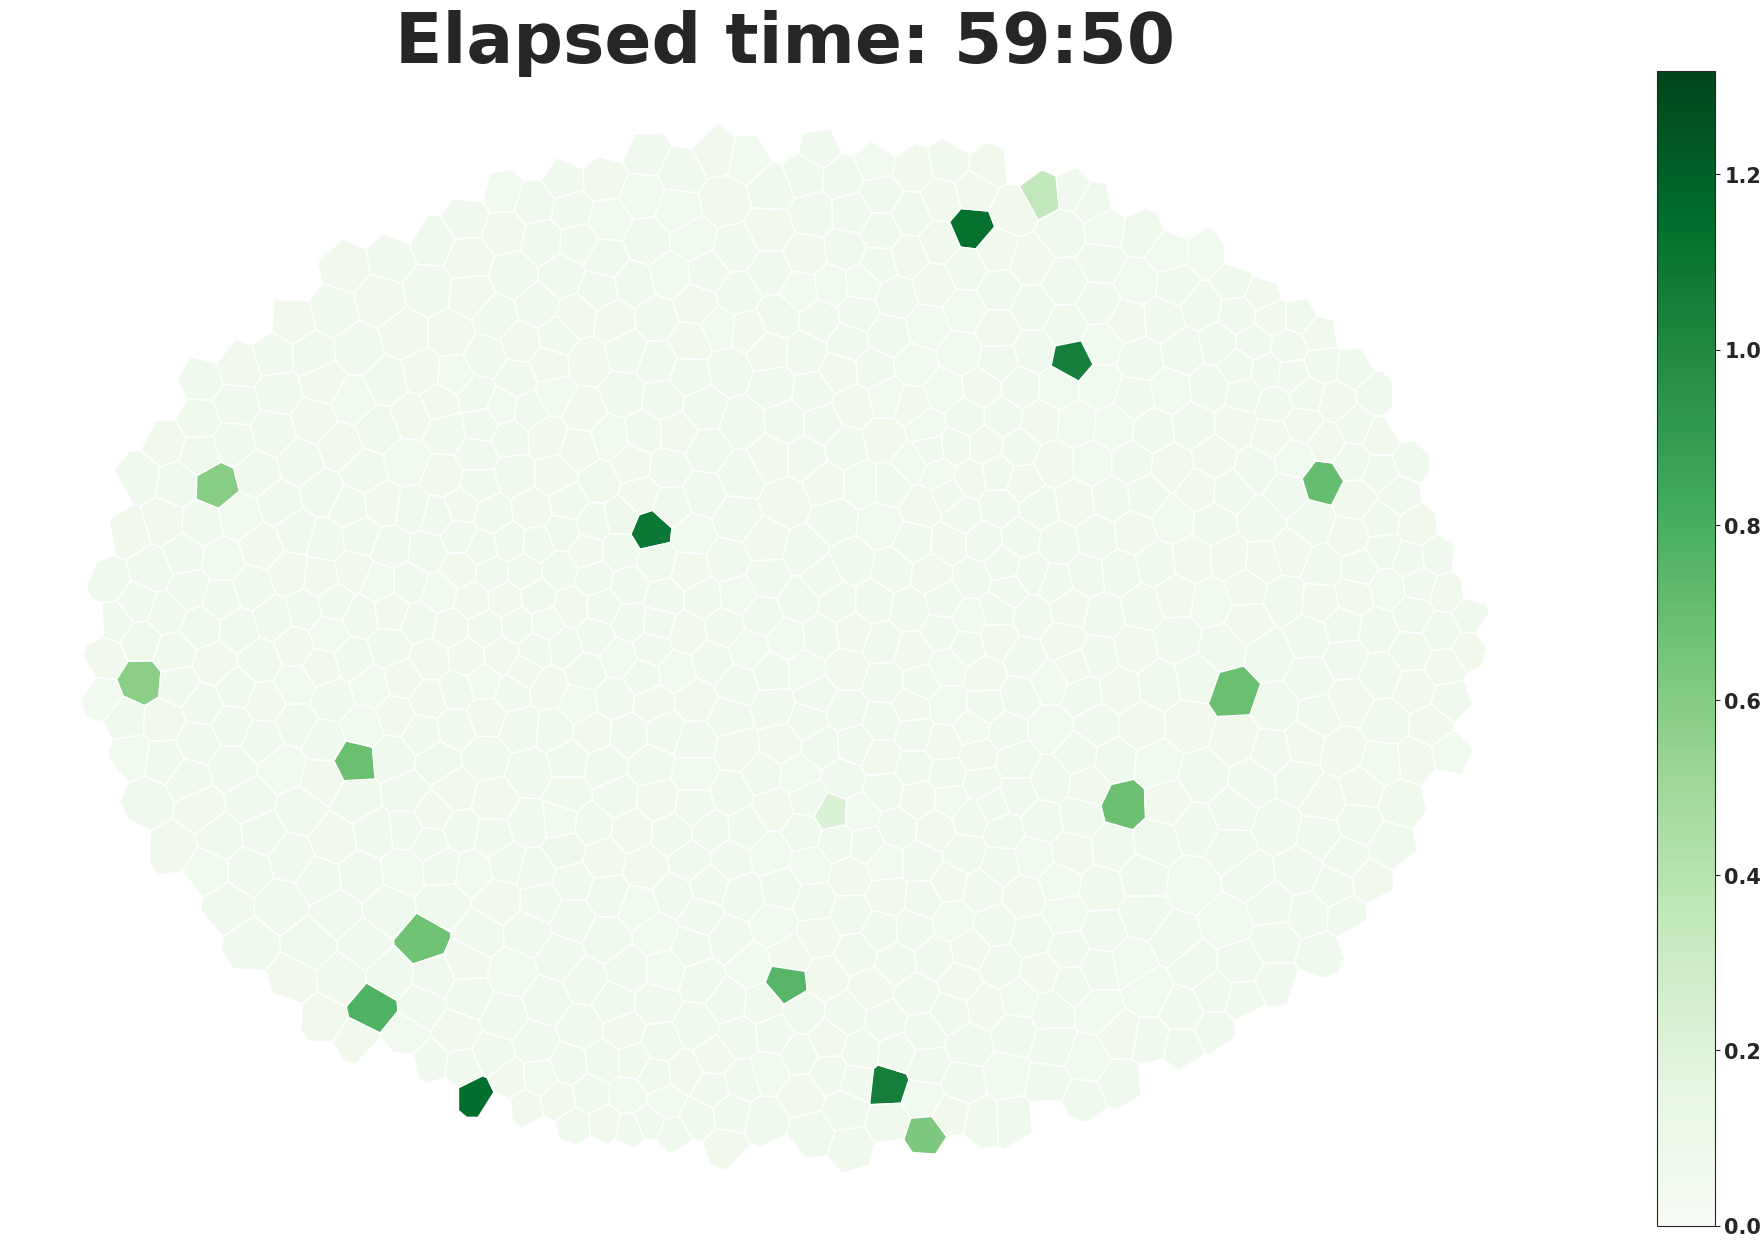

In [19]:
disc_model_sparse.make_animation(path=folder_path)



/Users/scini/Documents/GitHub/MSELab_Calcium_Cartography_2021/ca_models_lib.py:402: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  cbar.ax.set_yticklabels(cbar.ax.get_yticklabels(), fontsize=15,fontweight="bold")


CalledProcessError: Command '['ffmpeg', '-f', 'rawvideo', '-vcodec', 'rawvideo', '-s', '2500x1500', '-pix_fmt', 'rgba', '-framerate', '14.285714285714286', '-loglevel', 'error', '-i', 'pipe:', '-vcodec', 'h264', '-pix_fmt', 'yuv420p', '-y', '/Users/scini/Library/CloudStorage/Box-Box/ZartmanLabGroupFolder/Zartman_Dowling/Stephen/MC2021_Data//smallDisc_12345_default.mp4']' returned non-zero exit status 255.

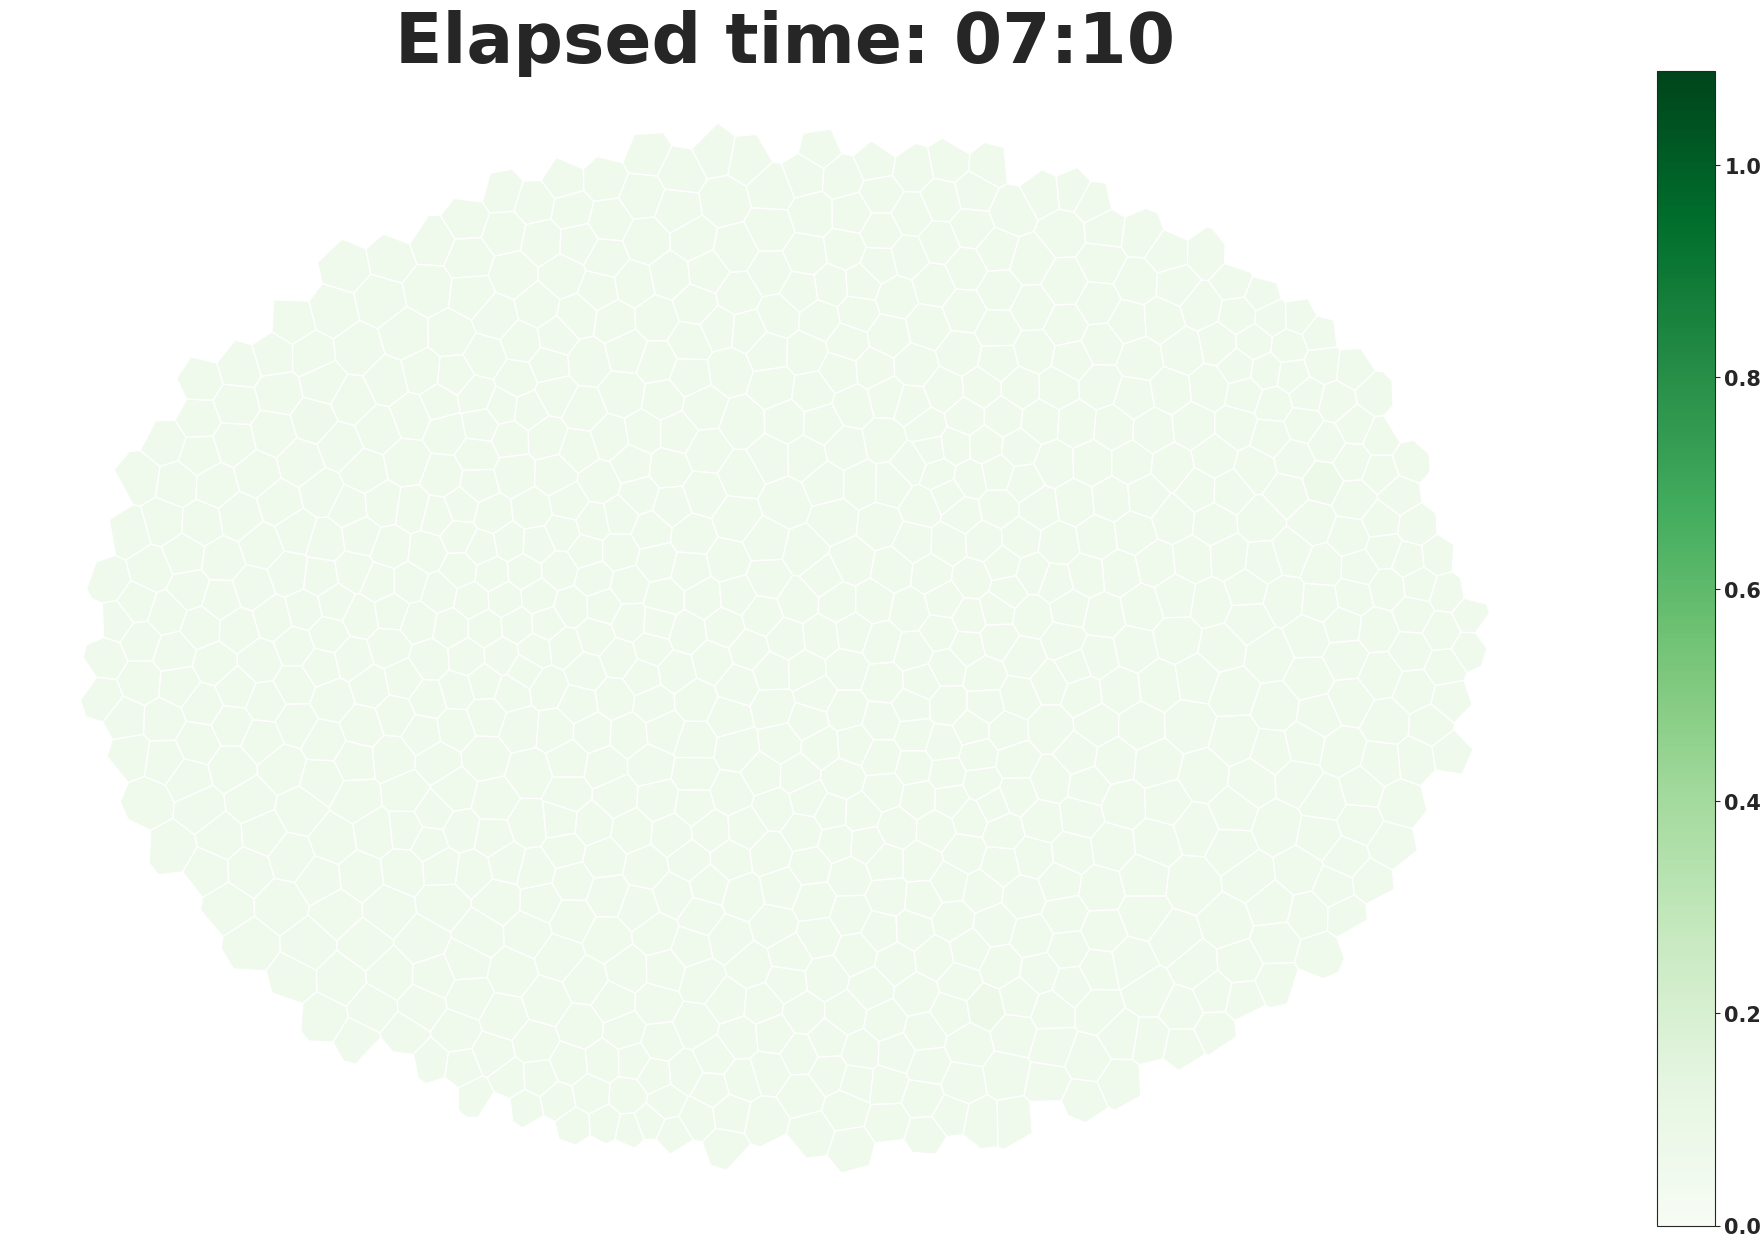

In [17]:
disc_model_sparse_noIP3.make_animation(path=folder_path)

/Users/scini/Documents/GitHub/MSELab_Calcium_Cartography_2021/ca_models_lib.py:491: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  cbar.ax.set_yticklabels(cbar.ax.get_yticklabels(), fontsize=80, fontweight="bold")


Provide a path for saving images
Provide a path for saving images


/Users/scini/Documents/GitHub/MSELab_Calcium_Cartography_2021/ca_models_lib.py:491: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  cbar.ax.set_yticklabels(cbar.ax.get_yticklabels(), fontsize=80, fontweight="bold")


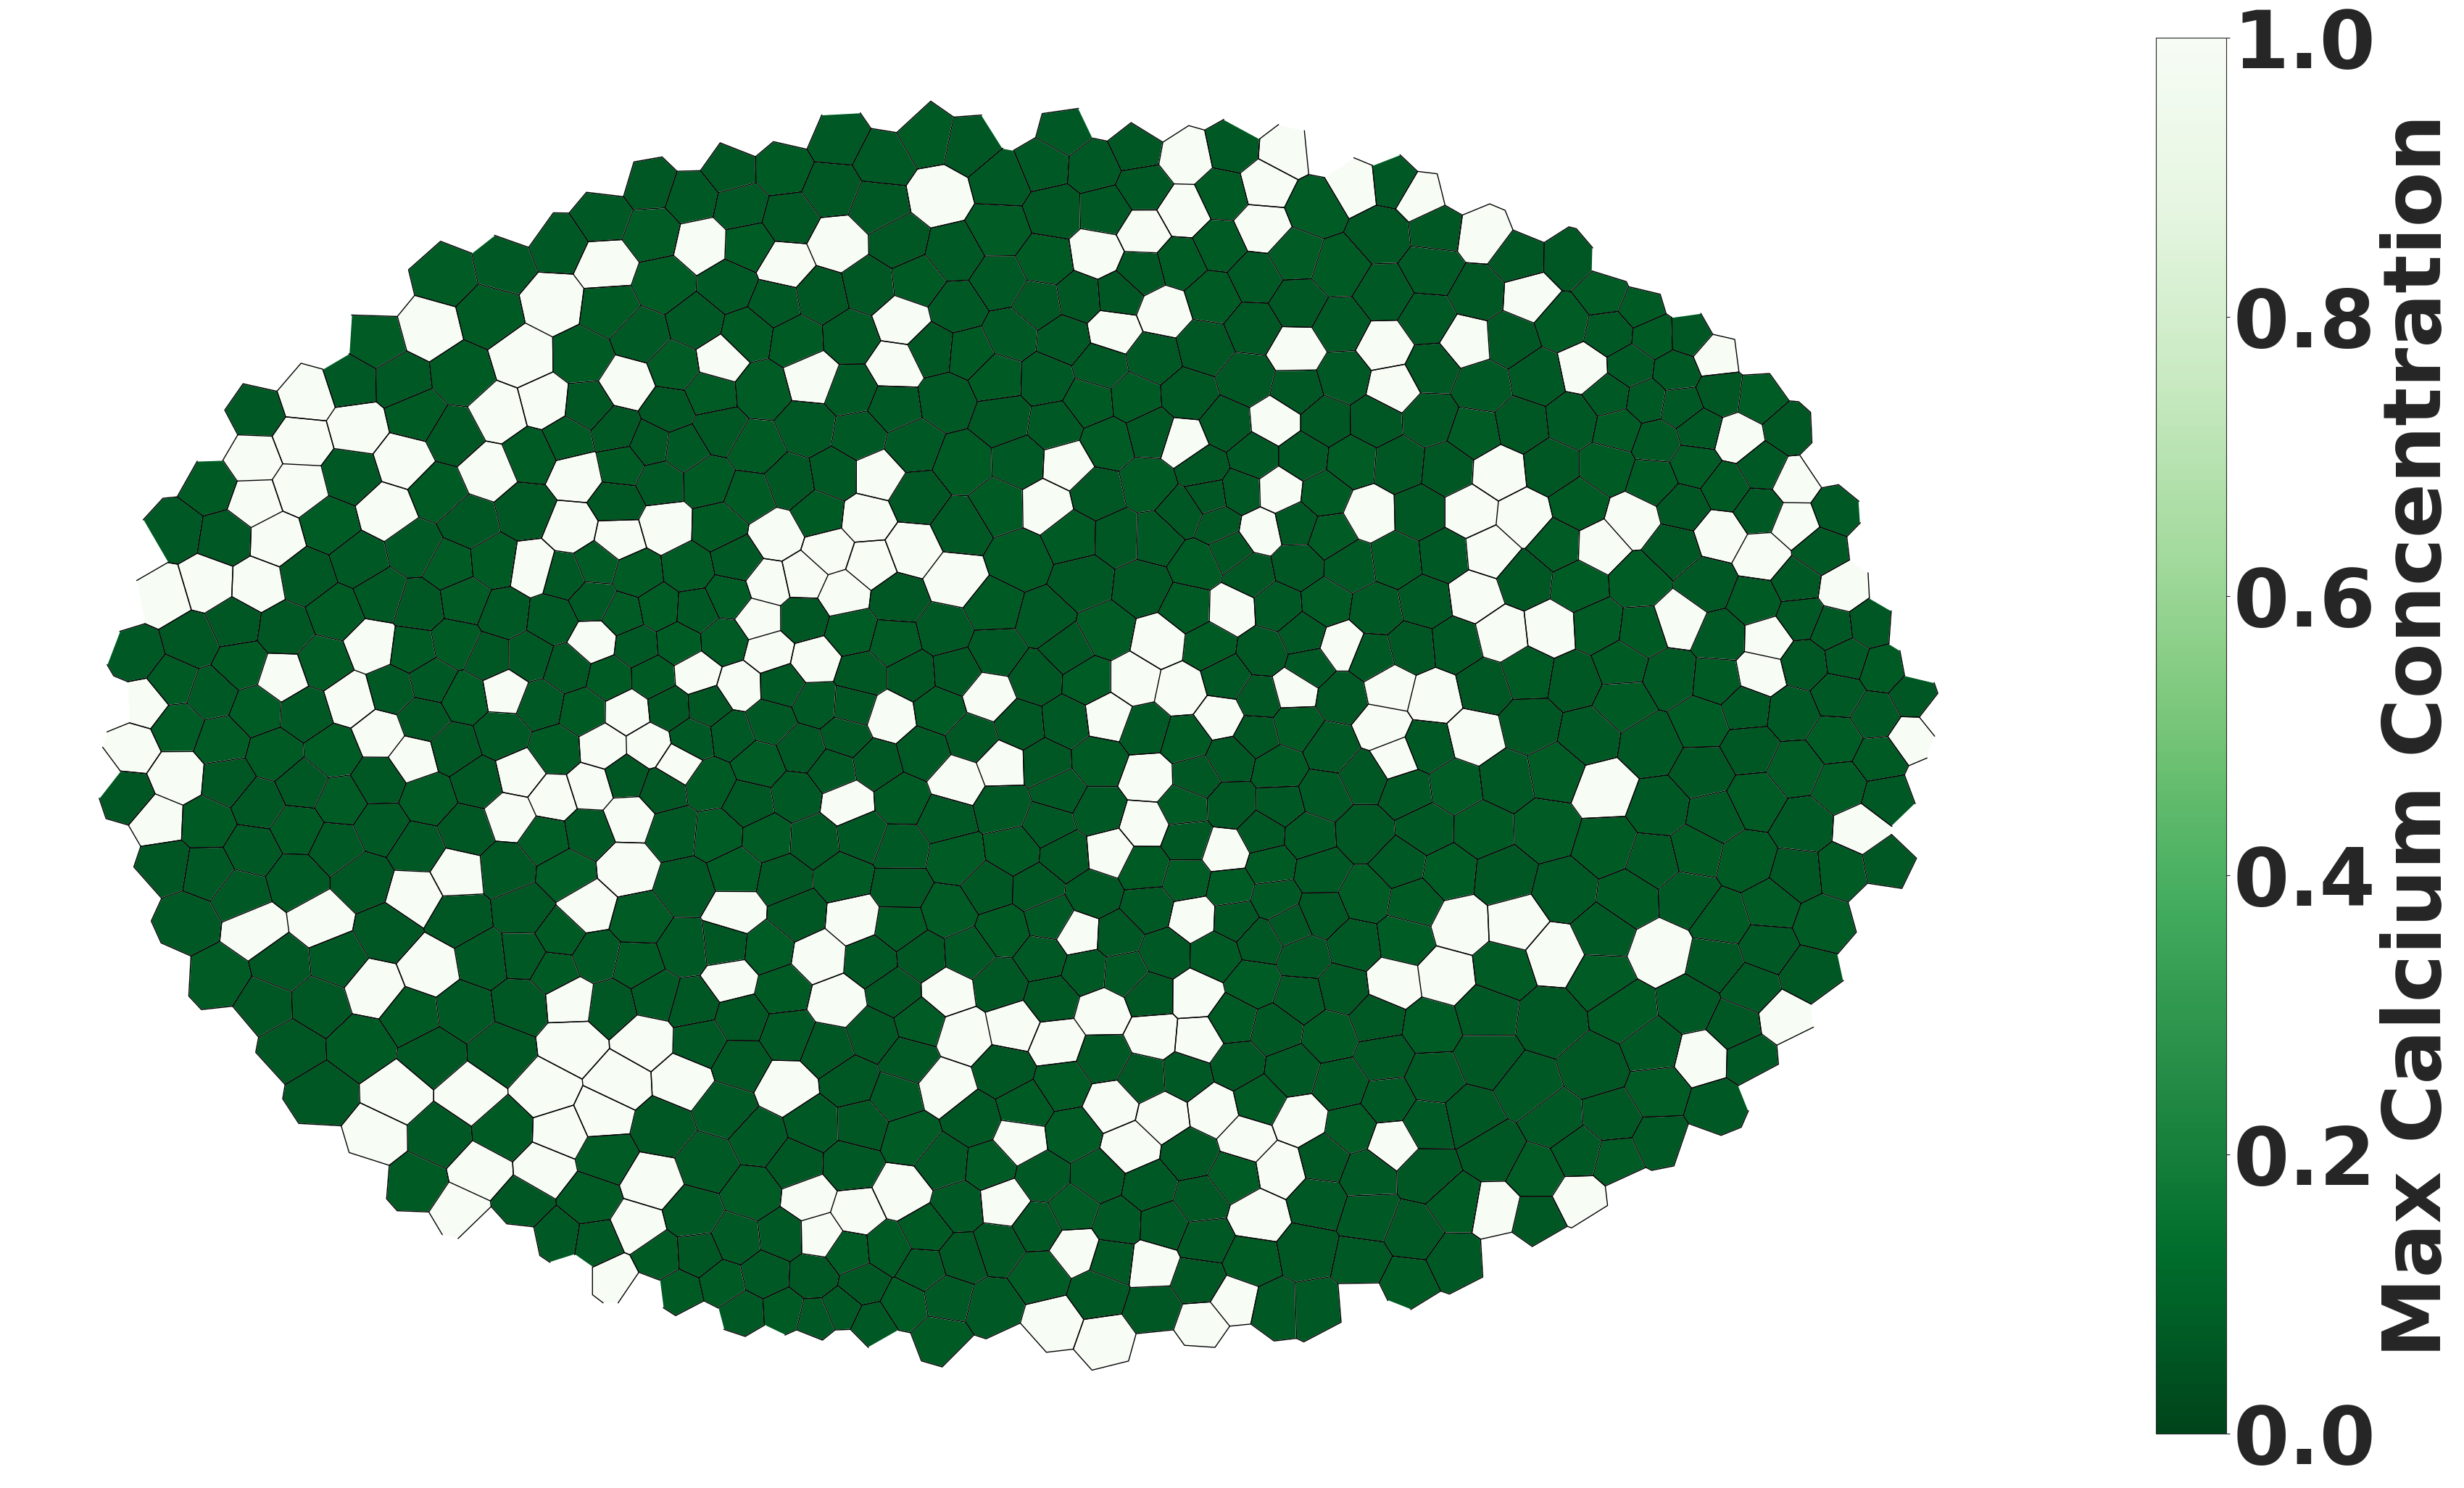

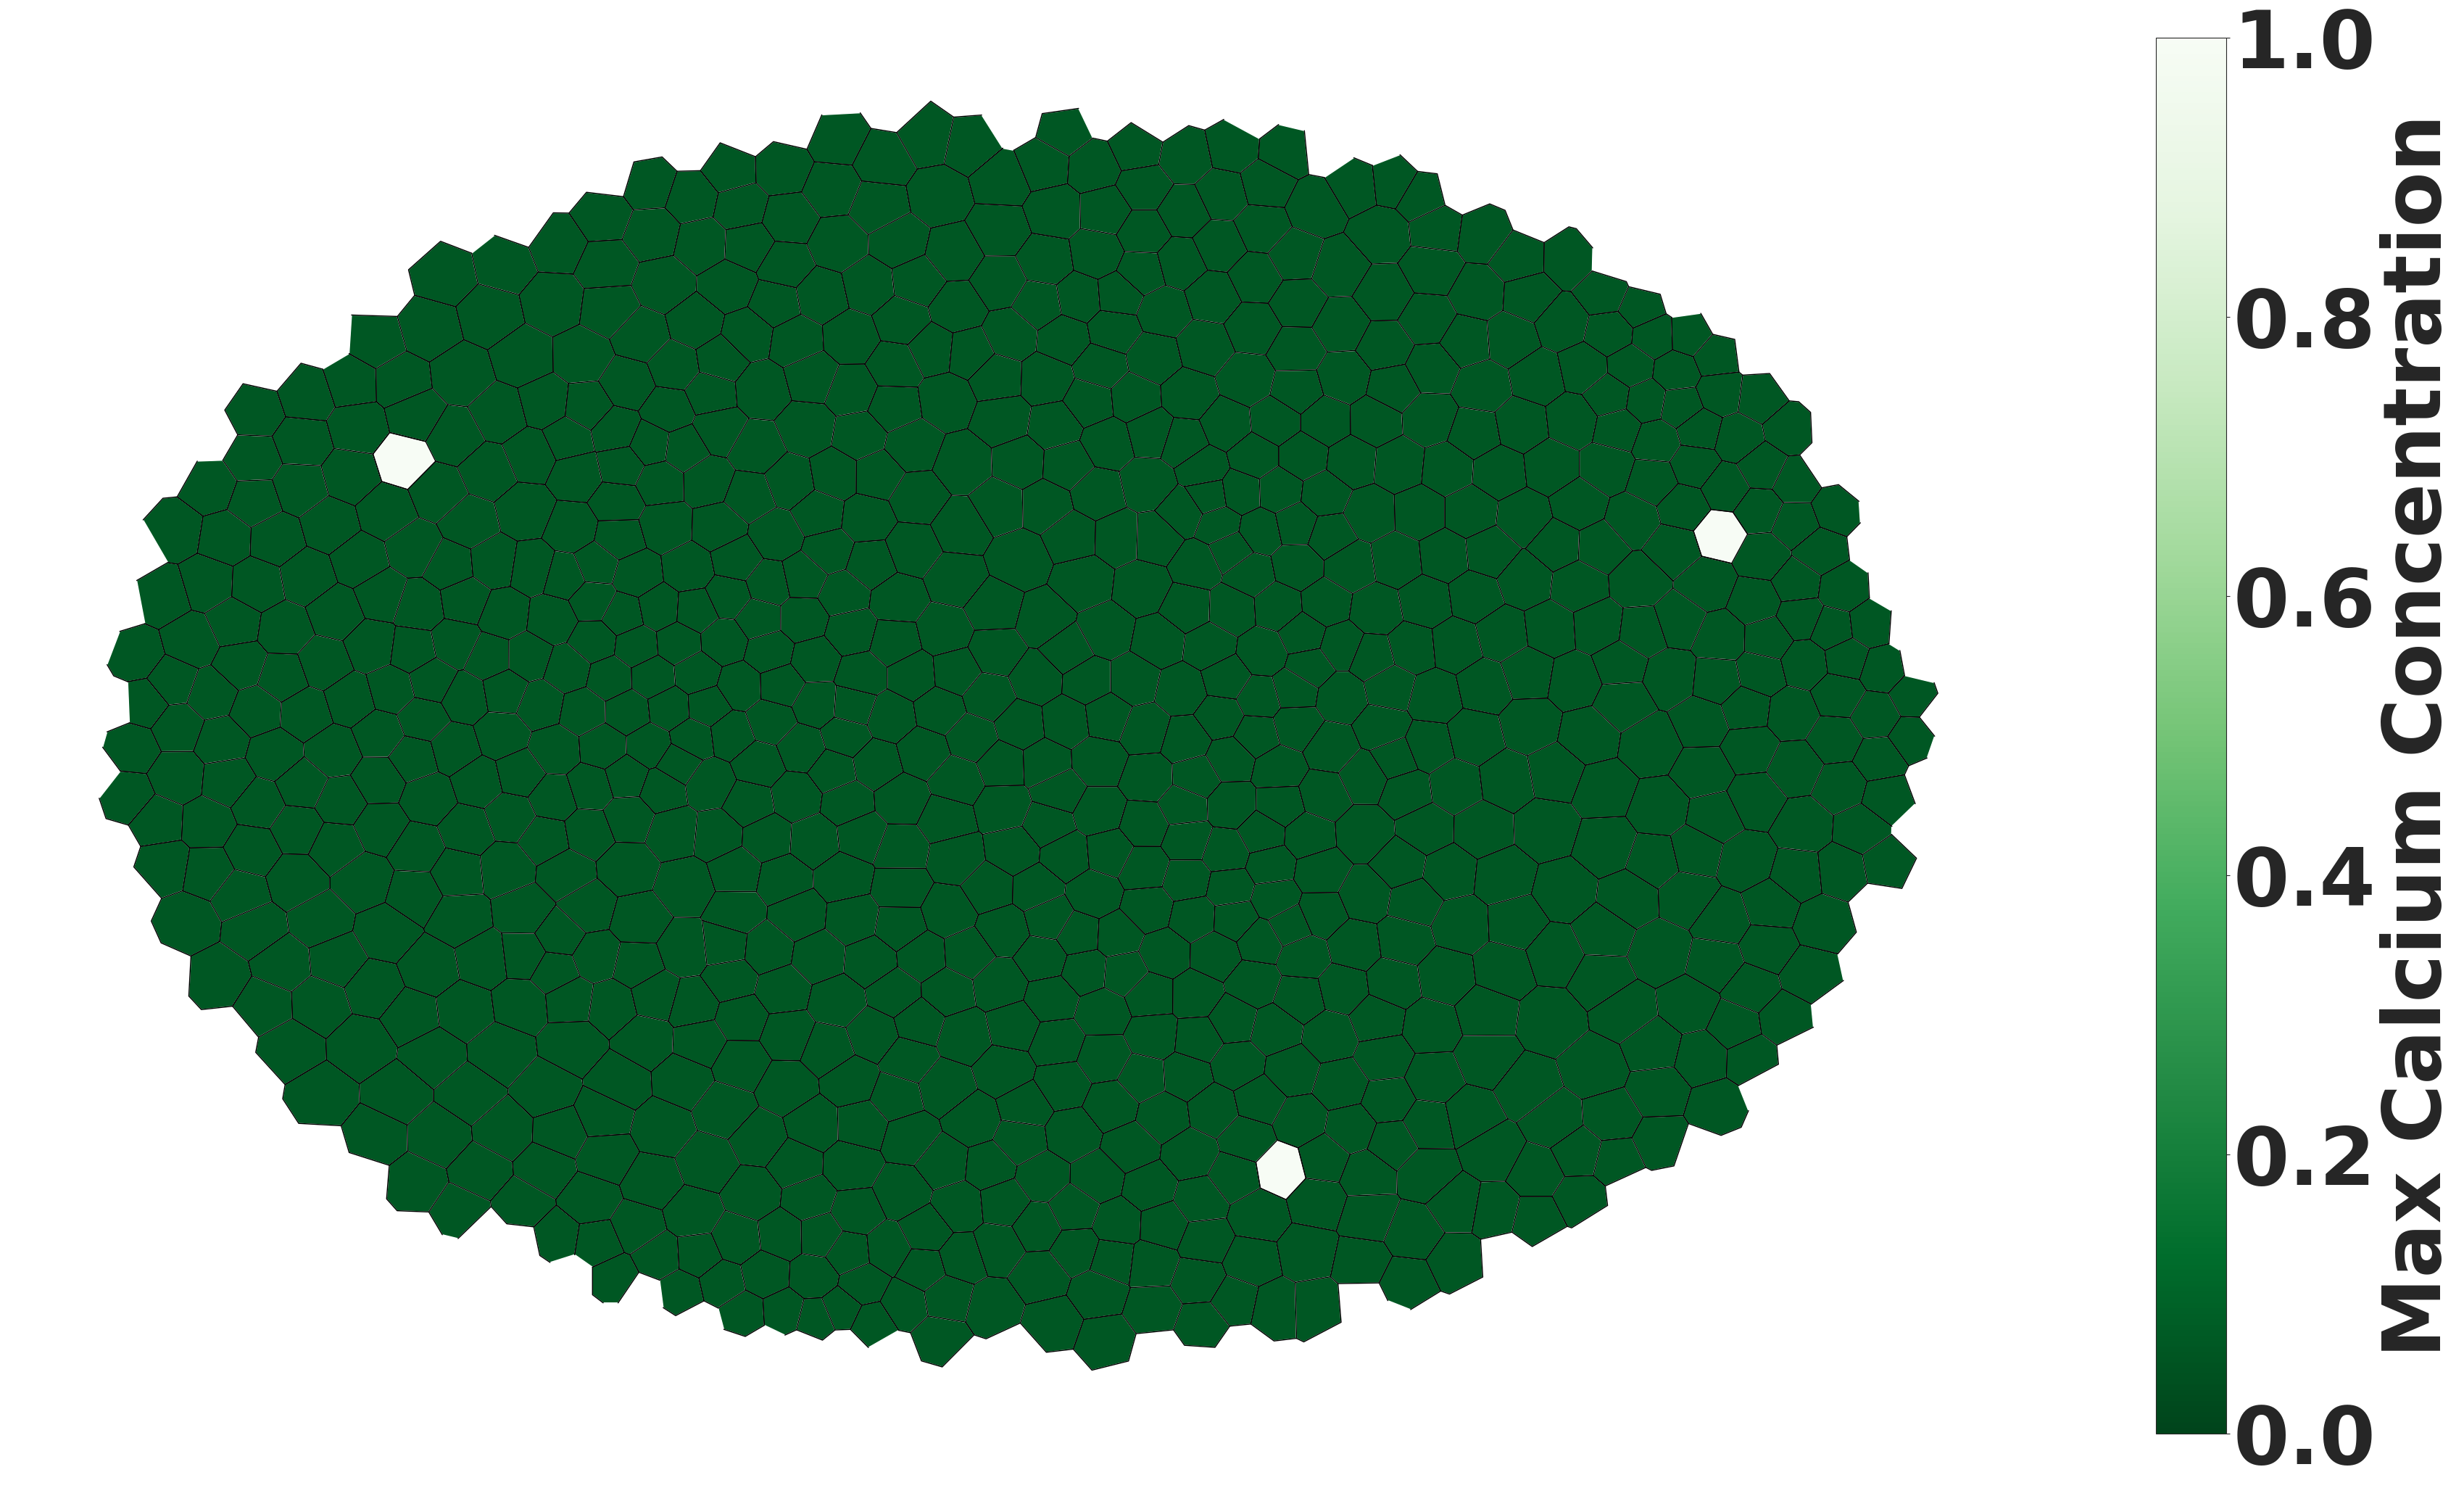

In [20]:
disc_model_sparse.draw_profile_ca2()
disc_model_sparse_noIP3.draw_profile_ca2()